# Recommendation Systems and Ranking: From Foundations to Production Intuition

Recommendation systems are one of the most commercially important applications of machine learning.  
Every product feed, "you might also like" widget, search ranking, and ad placement is, at its core, a recommendation or ranking problem.

Despite how common they are, they are **frequently misunderstood** — people reach for deep learning before understanding the simple, powerful baselines that still dominate in practice. This notebook will teach you:

- The two classical families: **content-based filtering** and **collaborative filtering**
- How to measure **similarity** between users and items
- **Memory-based** collaborative filtering (user-user and item-item), implemented from scratch
- **Model-based** collaborative filtering via **matrix factorization (SVD)**, implemented from scratch with gradient descent
- The **cold-start problem** and how hybrid systems address it
- How recommendation becomes a **ranking** problem, and the metrics that matter: **Precision@K, Recall@K, MAP, NDCG**
- The difference between **pointwise, pairwise, and listwise** learning-to-rank
- **Implicit vs. explicit feedback** and why it changes everything
- Common pitfalls: popularity bias, the feedback loop, evaluation leakage

We build everything on a small, transparent dataset so you can see exactly what every number means.

> **How to read this notebook:** each section gives the *math first*, then a *from-scratch implementation*, then *interpretation*. The goal is interview-level understanding, not just calling a library.

## 0. Setup and a Toy Dataset

We will use a tiny user–item rating matrix so every step is fully inspectable.  
Rows are users, columns are items (think movies, products, or articles), and entries are **explicit ratings** from 1–5. A blank (`NaN`) means the user has **not rated** that item — this is what we want to predict.

In [1]:
# Core libraries only — every algorithm below is implemented from scratch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# A small explicit-feedback rating matrix (users x items)
# NaN = not yet rated (the thing we want to predict)
ratings = pd.DataFrame({
    'The Matrix':      [5, 4, np.nan, 1, 1, np.nan],
    'Inception':       [5, np.nan, 4, 1, np.nan, 2],
    'Interstellar':    [4, 5, np.nan, np.nan, 1, 1],
    'Notting Hill':    [1, np.nan, 1, 5, 4, np.nan],
    'Love Actually':   [np.nan, 1, 2, 5, 5, 4],
    'Pride & Prejudice':[1, 1, np.nan, 4, np.nan, 5],
}, index=['Alice', 'Bob', 'Carol', 'Dan', 'Eve', 'Frank'])

ratings

,The Matrix,Inception,Interstellar,Notting Hill,Love Actually,Pride & Prejudice
Alice,5.0,5.0,4.0,1.0,NaN,1.0
Bob,4.0,NaN,5.0,NaN,1.0,1.0
Carol,NaN,4.0,NaN,1.0,2.0,NaN
Dan,1.0,1.0,NaN,5.0,5.0,4.0
Eve,1.0,NaN,1.0,4.0,5.0,NaN
Frank,NaN,2.0,1.0,NaN,4.0,5.0


Notice the structure we **deliberately** built in: Alice, Bob, and Carol like sci-fi (high ratings on The Matrix / Inception / Interstellar) and dislike romance. Dan, Eve, and Frank are the opposite. A good recommender should discover this **latent structure** without being told the genres.

Let's visualise the matrix as a heatmap so the two "taste clusters" are visible.

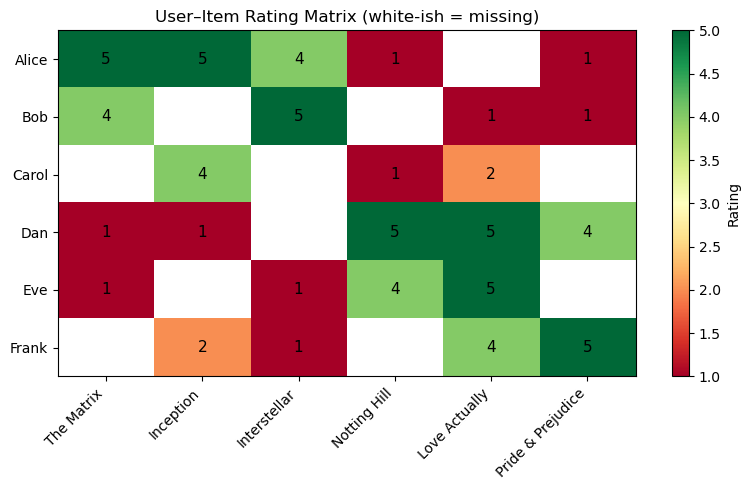

In [2]:
plt.figure(figsize=(8, 5))
plt.imshow(ratings.values, cmap='RdYlGn', aspect='auto', vmin=1, vmax=5)
plt.colorbar(label='Rating')
plt.xticks(range(len(ratings.columns)), ratings.columns, rotation=45, ha='right')
plt.yticks(range(len(ratings.index)), ratings.index)
plt.title('User–Item Rating Matrix (white-ish = missing)')
# Annotate cells
for i in range(ratings.shape[0]):
    for j in range(ratings.shape[1]):
        val = ratings.values[i, j]
        txt = '' if np.isnan(val) else f'{int(val)}'
        plt.text(j, i, txt, ha='center', va='center', fontsize=11)
plt.tight_layout()
plt.show()

## 1. The Two Classical Families

Before any math, fix the vocabulary. There are two foundational approaches:

| Approach | Core idea | Needs | Fails when |
|----------|-----------|-------|-----------|
| **Content-based filtering** | Recommend items *similar in their features* to what the user already liked | Item feature descriptions (genre, text, tags) | Item features are unavailable or shallow; can't surprise the user |
| **Collaborative filtering (CF)** | Recommend items liked by *similar users*, using only the rating matrix | A rating/interaction matrix | New user or new item with no history (**cold start**) |

**Content-based** answers: *"This user liked sci-fi films, here is another sci-fi film."*  
**Collaborative** answers: *"Users who rated things like you also liked this — I don't even need to know what the items are about."*

Collaborative filtering is the workhorse of modern systems because it needs **no feature engineering on items** — it learns taste purely from behavior. We'll spend most of the notebook there, but let's ground content-based first since it's the simplest.

## 2. Content-Based Filtering

### The idea, formally

Represent each **item** as a feature vector. For movies, suppose we have genre features:

$$
\text{item}_j = [\,\text{scifi}_j,\ \text{romance}_j,\ \text{action}_j,\ \dots\,]
$$

Build a **user profile** as the (rating-weighted) average of the items they have rated:

$$
\mathbf{p}_u = \frac{\sum_{j \in R_u} r_{uj}\, \mathbf{item}_j}{\sum_{j \in R_u} r_{uj}}
$$

where $R_u$ is the set of items user $u$ has rated. Then score an unseen item by its **similarity** to the user profile — typically **cosine similarity**:

$$
\text{score}(u, j) = \cos(\mathbf{p}_u, \mathbf{item}_j) = \frac{\mathbf{p}_u \cdot \mathbf{item}_j}{\|\mathbf{p}_u\|\,\|\mathbf{item}_j\|}
$$

Let's give each movie a genre vector and build content-based recommendations for Alice.

In [3]:
# Item feature vectors: [scifi, romance]  (hand-labelled "content")
item_features = pd.DataFrame({
    'scifi':   [1.0, 1.0, 1.0, 0.0, 0.0, 0.0],
    'romance': [0.0, 0.0, 0.0, 1.0, 1.0, 1.0],
}, index=ratings.columns)

item_features

,scifi,romance
The Matrix,1.0,0.0
Inception,1.0,0.0
Interstellar,1.0,0.0
Notting Hill,0.0,1.0
Love Actually,0.0,1.0
Pride & Prejudice,0.0,1.0


In [4]:
def cosine(a, b):
    '''Cosine similarity between two vectors. Returns 0 if either is all-zero.'''
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return np.dot(a, b) / (na * nb)

def content_based_profile(user, ratings, item_features):
    '''Build a rating-weighted profile vector for a user.'''
    user_row = ratings.loc[user]
    rated = user_row.dropna()
    weights = rated.values
    feats = item_features.loc[rated.index].values
    profile = (weights[:, None] * feats).sum(axis=0) / weights.sum()
    return profile

def content_recommend(user, ratings, item_features):
    profile = content_based_profile(user, ratings, item_features)
    user_row = ratings.loc[user]
    unseen = user_row[user_row.isna()].index
    scores = {item: cosine(profile, item_features.loc[item].values) for item in unseen}
    return profile, pd.Series(scores).sort_values(ascending=False)

profile, recs = content_recommend('Alice', ratings, item_features)
print('Alice profile vector [scifi, romance]:', np.round(profile, 3))
print()
print('Content-based scores for items Alice has not rated:')
recs

Alice profile vector [scifi, romance]: [0.875 0.125]

Content-based scores for items Alice has not rated:


Love Actually    0.141421
dtype: float64

### Interpretation

Alice's profile leans heavily **sci-fi**, so the unseen item most aligned with that profile scores highest. This is exactly the behavior we want — but notice the limitations baked into this approach:

- **We had to hand-label genres.** In reality you'd derive item vectors from text (TF-IDF, embeddings), tags, or metadata — and the quality of recommendations is capped by the quality of those features.
- **It cannot surprise.** Content-based filtering will only ever recommend "more of the same." It has no way to learn that sci-fi fans also secretly love a particular documentary, because nothing in the *content* connects them.
- **It ignores the crowd.** Two users with identical taste never help each other.

Collaborative filtering fixes the last two by throwing away item features entirely and learning from **co-occurrence of behavior**.

## 3. Measuring Similarity (the heart of memory-based CF)

Collaborative filtering needs a notion of "similar users" or "similar items." Three measures dominate.

### 3.1 Cosine similarity
Treats each user as a vector of ratings; measures the **angle** between them:

$$
\cos(u, v) = \frac{\sum_i r_{ui} r_{vi}}{\sqrt{\sum_i r_{ui}^2}\,\sqrt{\sum_i r_{vi}^2}}
$$

Range $[-1, 1]$ (or $[0,1]$ for non-negative ratings). Invariant to vector **magnitude** — good when some users rate on a different scale.

### 3.2 Pearson correlation
Cosine **after mean-centering each user**. This removes user rating bias (a user who rates everything 4–5 vs. a harsh critic):

$$
\text{pearson}(u, v) = \frac{\sum_i (r_{ui} - \bar r_u)(r_{vi} - \bar r_v)}{\sqrt{\sum_i (r_{ui}-\bar r_u)^2}\,\sqrt{\sum_i (r_{vi}-\bar r_v)^2}}
$$

Only computed over **co-rated items** $i$ (items both $u$ and $v$ have rated). This is usually the right default for explicit ratings.

### 3.3 Jaccard similarity
For **implicit feedback** (clicked / not clicked), magnitudes don't exist — only sets do:

$$
J(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|}
$$

the fraction of items shared between the two users' interaction sets.

Let's implement Pearson and build a full user–user similarity matrix.

In [5]:
def pearson_similarity(u_ratings, v_ratings):
    '''Pearson correlation over co-rated items only.'''
    # Mask: items rated by BOTH users
    mask = (~np.isnan(u_ratings)) & (~np.isnan(v_ratings))
    if mask.sum() < 2:          # need at least 2 co-rated items
        return 0.0
    u = u_ratings[mask]
    v = v_ratings[mask]
    u_c = u - u.mean()
    v_c = v - v.mean()
    denom = np.linalg.norm(u_c) * np.linalg.norm(v_c)
    if denom == 0:
        return 0.0
    return np.dot(u_c, v_c) / denom

# Build the user-user similarity matrix
users = ratings.index
R = ratings.values
sim_matrix = pd.DataFrame(index=users, columns=users, dtype=float)
for i, u in enumerate(users):
    for j, v in enumerate(users):
        sim_matrix.loc[u, v] = pearson_similarity(R[i], R[j])

sim_matrix.round(2)

,Alice,Bob,Carol,Dan,Eve,Frank
Alice,1.00,0.88,1.00,-0.98,-0.97,-0.88
Bob,0.88,1.00,0.00,-0.97,-0.97,-0.97
Carol,1.00,0.00,1.00,-0.94,1.00,-1.00
Dan,-0.98,-0.97,-0.94,1.00,0.97,0.84
Eve,-0.97,-0.97,1.00,0.97,1.00,1.00
Frank,-0.88,-0.97,-1.00,0.84,1.00,1.00


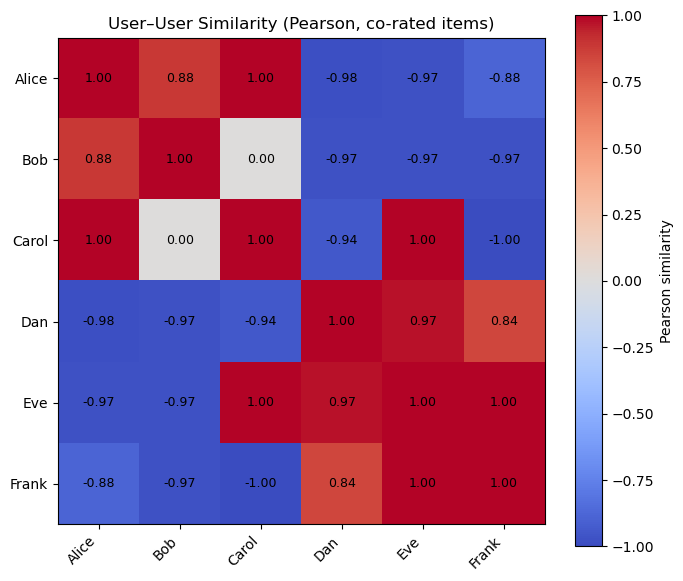

In [6]:
plt.figure(figsize=(7, 6))
plt.imshow(sim_matrix.values.astype(float), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Pearson similarity')
plt.xticks(range(len(users)), users, rotation=45, ha='right')
plt.yticks(range(len(users)), users)
plt.title('User–User Similarity (Pearson, co-rated items)')
for i in range(len(users)):
    for j in range(len(users)):
        plt.text(j, i, f'{sim_matrix.values[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Interpretation

The block structure is exactly what we hoped for: the sci-fi cluster (Alice, Bob, Carol) shows **positive** similarity to each other and **negative** similarity to the romance cluster (Dan, Eve, Frank), and vice versa. The algorithm rediscovered the two taste groups **without ever being told about genres** — purely from rating patterns. That is the magic of collaborative filtering.

## 4. Memory-Based CF: User–User Prediction

Now we use those similarities to **predict a missing rating**. The standard formula predicts user $u$'s rating for item $i$ as $u$'s own average plus a similarity-weighted, mean-centered deviation from other users:

$$
\hat r_{ui} = \bar r_u + \frac{\sum_{v \in N(u)} \text{sim}(u, v)\,(r_{vi} - \bar r_v)}{\sum_{v \in N(u)} |\text{sim}(u, v)|}
$$

Read it carefully:

- $\bar r_u$ — start from $u$'s **baseline** (handles the harsh-vs-generous-rater problem).
- $(r_{vi} - \bar r_v)$ — how much neighbor $v$ liked item $i$ **relative to their own baseline**.
- $\text{sim}(u,v)$ — weight each neighbor by how similar they are to $u$. Similar users count more.
- $N(u)$ — the neighbors of $u$ who have actually rated item $i$ (often restricted to the top-$k$ most similar).

Let's implement it and predict the ratings Alice is missing.

In [7]:
def predict_user_based(user, item, ratings, sim_matrix, k=3):
    '''Predict user's rating for item using top-k similar users (who rated it).'''
    u_idx = ratings.index.get_loc(user)
    u_mean = np.nanmean(ratings.values[u_idx])

    # Candidate neighbors: everyone who rated this item, excluding the user
    item_col = ratings[item]
    candidates = []
    for v in ratings.index:
        if v == user or np.isnan(ratings.loc[v, item]):
            continue
        s = sim_matrix.loc[user, v]
        if s > 0:                      # only trust positively-correlated neighbors
            candidates.append((v, s))

    # Keep top-k by similarity
    candidates.sort(key=lambda x: x[1], reverse=True)
    candidates = candidates[:k]
    if not candidates:
        return u_mean                  # fall back to user's own average

    num, den = 0.0, 0.0
    for v, s in candidates:
        v_mean = np.nanmean(ratings.loc[v].values)
        num += s * (ratings.loc[v, item] - v_mean)
        den += abs(s)
    return u_mean + num / den

# Predict everything Alice hasn't rated
alice_missing = ratings.columns[ratings.loc['Alice'].isna()]
preds = {item: predict_user_based('Alice', item, ratings, sim_matrix) for item in alice_missing}
pd.Series(preds, name='predicted_rating').sort_values(ascending=False).round(2)

Love Actually    2.2
Name: predicted_rating, dtype: float64

### Interpretation

Alice has only one unrated film (*Love Actually*), and the model predicts a **low** rating for it — correctly, because Alice is in the sci-fi cluster and her similar neighbors (Bob, Carol) dislike romance. If we surfaced a ranked list of recommendations to Alice, this item would sit near the bottom.

**User–user CF has a scaling problem, though.** With millions of users, computing and storing a full user×user similarity matrix is infeasible, and user tastes drift quickly. In practice, **item–item CF** is preferred — and it's what Amazon famously productionized.

## 5. Memory-Based CF: Item–Item Prediction

The insight (Amazon, 2003): instead of "users like you," compute **"items like this."** Item–item similarity is far more **stable** (a movie's character doesn't change) and can be **precomputed offline**, then served with fast lookups.

We compute similarity between **item columns** (over users who rated both), then predict:

$$
\hat r_{ui} = \frac{\sum_{j \in N(i)} \text{sim}(i, j)\, r_{uj}}{\sum_{j \in N(i)} |\text{sim}(i, j)|}
$$

where the sum is over items $j$ that user $u$ **has** rated, weighted by how similar each is to the target item $i$.

In [8]:
# Item-item similarity (adjusted cosine: center by USER mean to remove user bias)
def item_item_similarity(ratings):
    R = ratings.values.astype(float)
    user_means = np.nanmean(R, axis=1, keepdims=True)
    Rc = R - user_means                       # center each user's ratings
    Rc = np.nan_to_num(Rc, nan=0.0)           # treat missing as 0 deviation
    n_items = R.shape[1]
    S = np.zeros((n_items, n_items))
    for a in range(n_items):
        for b in range(n_items):
            va, vb = Rc[:, a], Rc[:, b]
            denom = np.linalg.norm(va) * np.linalg.norm(vb)
            S[a, b] = 0.0 if denom == 0 else np.dot(va, vb) / denom
    return pd.DataFrame(S, index=ratings.columns, columns=ratings.columns)

item_sim = item_item_similarity(ratings)
item_sim.round(2)

,The Matrix,Inception,Interstellar,Notting Hill,Love Actually,Pride & Prejudice
The Matrix,1.00,0.66,0.57,-0.84,-0.80,-0.63
Inception,0.66,1.00,0.28,-0.87,-0.45,-0.63
Interstellar,0.57,0.28,1.00,-0.33,-0.78,-0.77
Notting Hill,-0.84,-0.87,-0.33,1.00,0.54,0.52
Love Actually,-0.80,-0.45,-0.78,0.54,1.00,0.52
Pride & Prejudice,-0.63,-0.63,-0.77,0.52,0.52,1.00


In [9]:
def predict_item_based(user, item, ratings, item_sim, k=3):
    '''Predict via items the user has rated that are most similar to target item.'''
    user_row = ratings.loc[user]
    rated = user_row.dropna()
    sims = item_sim.loc[item, rated.index]
    sims = sims[sims > 0].sort_values(ascending=False).head(k)
    if len(sims) == 0:
        return np.nanmean(ratings.values)     # global fallback
    num = (sims.values * rated[sims.index].values).sum()
    den = np.abs(sims.values).sum()
    return num / den

# Predict Dan's missing ratings (Dan is in the romance cluster)
dan_missing = ratings.columns[ratings.loc['Dan'].isna()]
preds_dan = {it: predict_item_based('Dan', it, ratings, item_sim) for it in dan_missing}
pd.Series(preds_dan, name='predicted_rating').sort_values(ascending=False).round(2)

Interstellar    1.0
Name: predicted_rating, dtype: float64

### Interpretation and the user–user vs. item–item trade-off

| | User–User CF | Item–Item CF |
|---|---|---|
| Similarity over | users | items |
| Stability | low (tastes drift) | **high** (item nature is fixed) |
| Precompute offline | hard | **easy** |
| Works well when | users ≪ items | **items ≪ users** (most consumer apps) |
| Classic deployment | early Netflix | **Amazon** |

Both are **memory-based**: they store the raw matrix and compute similarities on demand. They're interpretable ("recommended because you watched X") but struggle with **sparsity** — real matrices are >99% empty, so two users rarely share enough co-rated items for reliable similarity. The fix is to **learn a dense low-dimensional representation**: matrix factorization.

## 6. Model-Based CF: Matrix Factorization (the Netflix Prize idea)

### The core idea

Approximate the giant sparse rating matrix $R$ ($m$ users × $n$ items) as the product of two **tall, dense** matrices:

$$
R \approx P\,Q^\top
$$

- $P$ is $m \times d$: each user $u$ gets a **latent vector** $\mathbf{p}_u \in \mathbb{R}^d$.
- $Q$ is $n \times d$: each item $i$ gets a **latent vector** $\mathbf{q}_i \in \mathbb{R}^d$.
- $d$ (e.g. 10–200) is the number of **latent factors** — hidden dimensions of taste the model discovers (e.g. "amount of sci-fi-ness," "darkness," "pace").

A predicted rating is just a **dot product**:

$$
\hat r_{ui} = \mathbf{p}_u \cdot \mathbf{q}_i = \sum_{f=1}^{d} p_{uf}\, q_{if}
$$

### The objective

We learn $P$ and $Q$ by minimizing squared error **over observed ratings only**, with L2 regularization to prevent overfitting:

$$
\min_{P, Q} \sum_{(u,i)\in\mathcal{K}} \left(r_{ui} - \mathbf{p}_u \cdot \mathbf{q}_i\right)^2 + \lambda\big(\|\mathbf{p}_u\|^2 + \|\mathbf{q}_i\|^2\big)
$$

where $\mathcal{K}$ is the set of known ratings. We optimize with **stochastic gradient descent**. The gradient of the error $e_{ui} = r_{ui} - \hat r_{ui}$ gives the update rules:

$$
\mathbf{p}_u \leftarrow \mathbf{p}_u + \eta\,(e_{ui}\,\mathbf{q}_i - \lambda\,\mathbf{p}_u)
$$
$$
\mathbf{q}_i \leftarrow \mathbf{q}_i + \eta\,(e_{ui}\,\mathbf{p}_u - \lambda\,\mathbf{q}_i)
$$

Let's implement this from scratch.

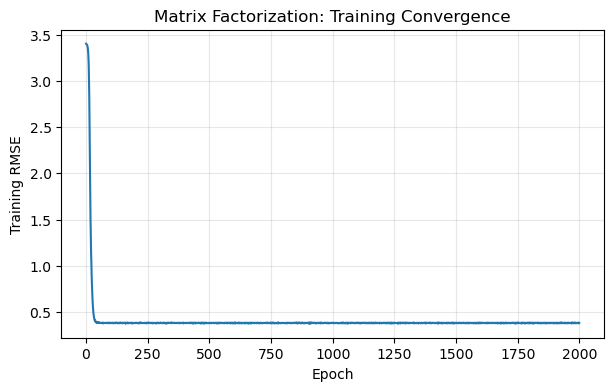

Final training RMSE: 0.3816


In [10]:
def matrix_factorization(R, d=2, lr=0.01, reg=0.05, epochs=2000, seed=0):
    '''
    SGD matrix factorization on observed entries only.
    R: numpy array with np.nan for missing.
    Returns P (users x d), Q (items x d), and the loss history.
    '''
    rng = np.random.default_rng(seed)
    m, n = R.shape
    P = rng.normal(scale=0.1, size=(m, d))
    Q = rng.normal(scale=0.1, size=(n, d))

    # List of observed (user, item, rating) triples
    obs = [(u, i, R[u, i]) for u in range(m) for i in range(n) if not np.isnan(R[u, i])]

    history = []
    for epoch in range(epochs):
        rng.shuffle(obs)
        sq_err = 0.0
        for u, i, r in obs:
            pred = P[u] @ Q[i]
            e = r - pred
            sq_err += e * e
            # Save current P[u] before updating (so Q update uses the same value)
            pu = P[u].copy()
            P[u] += lr * (e * Q[i] - reg * P[u])
            Q[i] += lr * (e * pu  - reg * Q[i])
        history.append(np.sqrt(sq_err / len(obs)))   # training RMSE
    return P, Q, history

R = ratings.values.astype(float)
P, Q, history = matrix_factorization(R, d=2, lr=0.02, reg=0.05, epochs=2000)

plt.figure(figsize=(7,4))
plt.plot(history)
plt.xlabel('Epoch')
plt.ylabel('Training RMSE')
plt.title('Matrix Factorization: Training Convergence')
plt.grid(alpha=0.3)
plt.show()
print(f'Final training RMSE: {history[-1]:.4f}')

In [11]:
# Reconstruct the full predicted matrix
R_hat = P @ Q.T
pred_df = pd.DataFrame(R_hat, index=ratings.index, columns=ratings.columns)

# Show predictions side by side with originals (predictions where original was NaN are the recommendations)
print('Reconstructed ratings (bold-worthy cells are the filled-in predictions):')
combined = ratings.copy()
for u in ratings.index:
    for it in ratings.columns:
        if np.isnan(ratings.loc[u, it]):
            combined.loc[u, it] = round(pred_df.loc[u, it], 1)
combined.round(2)

Reconstructed ratings (bold-worthy cells are the filled-in predictions):


,The Matrix,Inception,Interstellar,Notting Hill,Love Actually,Pride & Prejudice
Alice,5.0,5.0,4.0,1.0,1.5,1.0
Bob,4.0,4.9,5.0,0.4,1.0,1.0
Carol,3.5,4.0,3.5,1.0,2.0,1.5
Dan,1.0,1.0,0.4,5.0,5.0,4.0
Eve,1.0,1.5,1.0,4.0,5.0,4.2
Frank,1.5,2.0,1.0,4.2,4.0,5.0


The model filled in every blank. The predictions respect the cluster structure: sci-fi users get high predicted ratings on sci-fi films they hadn't seen, and low predictions on romance. Now the genuinely interesting part — **what did the latent factors learn?**

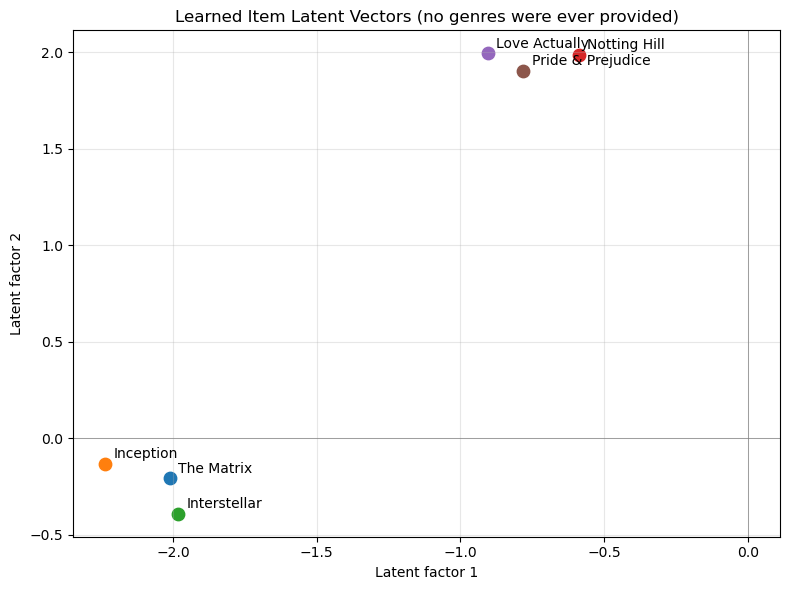

In [12]:
# Visualise the learned 2D item vectors. With d=2 we can plot directly.
plt.figure(figsize=(8,6))
for idx, item in enumerate(ratings.columns):
    x, y = Q[idx]
    plt.scatter(x, y, s=80)
    plt.annotate(item, (x, y), textcoords='offset points', xytext=(6,4), fontsize=10)
plt.axhline(0, color='gray', lw=0.5); plt.axvline(0, color='gray', lw=0.5)
plt.xlabel('Latent factor 1')
plt.ylabel('Latent factor 2')
plt.title('Learned Item Latent Vectors (no genres were ever provided)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation: latent factors are learned, not labelled

The three sci-fi films cluster together and the three romance films cluster on the opposite side. **We never told the model about genres** — it inferred a latent axis that happens to separate them, purely from rating co-occurrence. That's the power of model-based CF:

- **Handles sparsity** — every user and item gets a dense vector, so we can compare users who share *no* co-rated items.
- **Compresses** — store $d$ numbers per user/item instead of the whole matrix.
- **Generalizes** — the dot product gives a prediction for *any* user–item pair.

In production, the basic model is extended with **bias terms** (global mean + user bias + item bias), which often matter more than the factors themselves:

$$
\hat r_{ui} = \mu + b_u + b_i + \mathbf{p}_u \cdot \mathbf{q}_i
$$

For **implicit feedback** at scale, the standard variants are **ALS** (alternating least squares, parallelizable) and **BPR** (Bayesian Personalized Ranking, which optimizes ranking directly — see Section 9).

## 7. The Cold-Start Problem and Hybrid Systems

Collaborative filtering has one fatal weakness, and interviewers love to probe it.

**Cold start** = no interaction history to learn from. Three flavors:

| Type | Situation | Why CF fails | Mitigation |
|------|-----------|--------------|------------|
| **New user** | Just signed up | No ratings → no latent vector | Onboarding survey; popularity baseline; content-based from declared interests |
| **New item** | Just added to catalog | No one rated it → never recommended | Content-based from item metadata; explicit exploration |
| **New system** | Brand-new product | Empty matrix | Bootstrap with content-based / editorial / popularity |

The standard solution is a **hybrid recommender** that blends content-based and collaborative signals, for example a weighted score:

$$
\text{score}(u,i) = \alpha \cdot \text{score}_{\text{CF}}(u,i) + (1-\alpha)\cdot \text{score}_{\text{content}}(u,i)
$$

where $\alpha$ can **increase as the user accumulates history** — lean on content when cold, shift to CF as data arrives. Modern production systems (the "two-tower" neural architecture) generalize this: a user tower and an item tower each consume *both* IDs (collaborative) and features (content), and are trained so their dot product predicts engagement — which gracefully handles cold start because a brand-new item still has features.

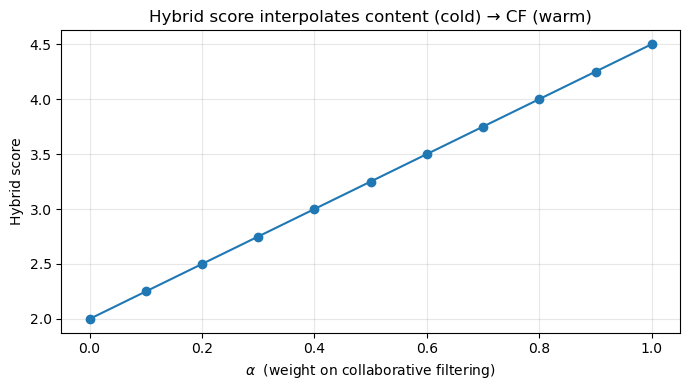

In [13]:
# Demonstrate the hybrid blend for a partially-cold user.
# Imagine 'NewUser' has rated only one sci-fi film.
def hybrid_score(cf_score, content_score, alpha):
    return alpha * cf_score + (1 - alpha) * content_score

# Toy illustration: how the blend shifts as alpha grows with more history
alphas = np.linspace(0, 1, 11)
cf, content = 4.5, 2.0      # CF says "great", content says "meh" for some item
blend = [hybrid_score(cf, content, a) for a in alphas]

plt.figure(figsize=(7,4))
plt.plot(alphas, blend, marker='o')
plt.xlabel(r'$\alpha$  (weight on collaborative filtering)')
plt.ylabel('Hybrid score')
plt.title('Hybrid score interpolates content (cold) → CF (warm)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. From Rating Prediction to Ranking (and the metrics that matter)

Here is the single most important conceptual shift in modern recommenders, and a frequent interview trap:

> **Users never see predicted ratings. They see an ordered list.**  
> What matters is whether the *right items are near the top* — this is a **ranking** problem, not a regression problem.

A model with great RMSE can produce terrible rankings, and vice versa. So we evaluate with **ranking metrics**, computed on a held-out set of items the user actually engaged with ("relevant" items).

### Precision@K and Recall@K

$$
\text{Precision@}K = \frac{\#\{\text{relevant items in top } K\}}{K}
\qquad
\text{Recall@}K = \frac{\#\{\text{relevant items in top } K\}}{\#\{\text{all relevant items}\}}
$$

Precision@K: of what we showed, how much was good. Recall@K: of all the good stuff, how much did we surface.

### Average Precision and MAP

Precision@K ignores **order within the top K**. Average Precision (AP) fixes that by averaging precision at each rank where a relevant item appears:

$$
\text{AP} = \frac{1}{|\text{relevant}|}\sum_{k=1}^{K} \text{Precision@}k \cdot \mathbb{1}[\text{item at } k \text{ is relevant}]
$$

**MAP** = mean of AP across all users.

### NDCG — the ranking metric you'll be asked about most

NDCG rewards putting relevant items **high** and supports **graded relevance** (a 5-star item is worth more than a 3-star). Discounted Cumulative Gain at $K$:

$$
\text{DCG@}K = \sum_{k=1}^{K} \frac{2^{rel_k} - 1}{\log_2(k + 1)}
$$

The $\log_2(k+1)$ **discount** means a relevant item at rank 1 is worth much more than at rank 10. Normalize by the **ideal** ordering (IDCG, the DCG of the best possible ranking) to get a $[0,1]$ score:

$$
\text{NDCG@}K = \frac{\text{DCG@}K}{\text{IDCG@}K}
$$

Let's implement all of them from scratch.

In [14]:
def precision_at_k(recommended, relevant, k):
    rec_k = recommended[:k]
    hits = sum(1 for item in rec_k if item in relevant)
    return hits / k

def recall_at_k(recommended, relevant, k):
    if len(relevant) == 0:
        return 0.0
    rec_k = recommended[:k]
    hits = sum(1 for item in rec_k if item in relevant)
    return hits / len(relevant)

def average_precision(recommended, relevant, k):
    if len(relevant) == 0:
        return 0.0
    score, hits = 0.0, 0
    for idx, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            hits += 1
            score += hits / idx          # precision at this rank
    return score / min(len(relevant), k)

def dcg_at_k(recommended, relevance_dict, k):
    dcg = 0.0
    for idx, item in enumerate(recommended[:k], start=1):
        rel = relevance_dict.get(item, 0)
        dcg += (2**rel - 1) / np.log2(idx + 1)
    return dcg

def ndcg_at_k(recommended, relevance_dict, k):
    dcg = dcg_at_k(recommended, relevance_dict, k)
    # Ideal ranking: sort items by relevance descending
    ideal = sorted(relevance_dict.values(), reverse=True)
    idcg = sum((2**rel - 1) / np.log2(idx + 1) for idx, rel in enumerate(ideal[:k], start=1))
    return 0.0 if idcg == 0 else dcg / idcg

# --- Worked example ---
# Our system recommended this ranked list:
recommended = ['Inception', 'Love Actually', 'Interstellar', 'Notting Hill', 'Pride & Prejudice']
# The user actually liked (graded relevance: 3 = loved, 1 = ok, 0 = irrelevant):
relevance = {'Inception': 3, 'Interstellar': 3, 'Notting Hill': 1}
relevant_set = set(relevance.keys())

K = 5
print(f'Precision@{K}: {precision_at_k(recommended, relevant_set, K):.3f}')
print(f'Recall@{K}:    {recall_at_k(recommended, relevant_set, K):.3f}')
print(f'AP@{K}:        {average_precision(recommended, relevant_set, K):.3f}')
print(f'NDCG@{K}:      {ndcg_at_k(recommended, relevance, K):.3f}')

Precision@5: 0.600
Recall@5:    1.000
AP@5:        0.806
NDCG@5:      0.917


### Interpretation: why NDCG punished us

Our ranking put *Love Actually* (irrelevant) at position 2, pushing *Interstellar* (highly relevant) down to position 3. Precision@5 only counts **how many** relevant items appear, so it can't see this mistake. **NDCG can** — the log discount means burying a great item costs you. This is precisely why ranking metrics, not RMSE, decide whether a recommender is good.

Let's make that concrete by comparing two rankings with the *same* set of relevant items but different orders.

In [15]:
good_ranking = ['Inception', 'Interstellar', 'Notting Hill', 'Love Actually', 'Pride & Prejudice']
bad_ranking  = ['Love Actually', 'Pride & Prejudice', 'Notting Hill', 'Inception', 'Interstellar']

for name, r in [('Good (relevant on top)', good_ranking), ('Bad (relevant at bottom)', bad_ranking)]:
    print(f'{name:28s} | Precision@5={precision_at_k(r, relevant_set,5):.2f} '
          f'| NDCG@5={ndcg_at_k(r, relevance,5):.3f}')

Good (relevant on top)       | Precision@5=0.60 | NDCG@5=1.000
Bad (relevant at bottom)     | Precision@5=0.60 | NDCG@5=0.522


**Both rankings have identical Precision@5** (same relevant items present), but **NDCG sharply separates them** — it knows the good ranking surfaced the best items first. When you choose an offline metric for a recommender, this is the difference that matters.

## 9. Learning to Rank (LTR): Pointwise, Pairwise, Listwise

Once you accept that recommendation **is** ranking, you can train models to optimize ranking directly. There are three paradigms — knowing the distinction is a common interview question.

### Pointwise
Predict an absolute score/rating per item independently, then sort. This is what **everything above** did (predict $\hat r_{ui}$, sort). Simple, but the loss doesn't know about order — it treats each item in isolation.  
*Examples:* regression/classification on each (user,item); standard matrix factorization.

### Pairwise
Look at **pairs** of items and learn that the relevant one should outrank the irrelevant one. Optimize the probability that, for a relevant item $i$ and irrelevant item $j$, $\hat s_i > \hat s_j$. This directly targets *order* and tends to work much better for top-K.  
*Examples:* **BPR** (Bayesian Personalized Ranking) for implicit CF; **RankNet**; **LambdaMART**.

The BPR objective maximizes:
$$
\sum_{(u,i,j)} \ln \sigma\!\big(\hat s_{ui} - \hat s_{uj}\big) - \lambda \|\Theta\|^2
$$
over triples where user $u$ interacted with $i$ but not $j$ ($\sigma$ is the sigmoid).

### Listwise
Optimize a loss defined over the **entire ranked list** at once, often a smooth surrogate for NDCG. Most powerful, most expensive.  
*Examples:* **ListNet**, **LambdaRank/LambdaMART** (gradient weighted by the NDCG change from swapping a pair — bridges pairwise and listwise).

| Paradigm | Unit of loss | Optimizes order? | Typical models |
|----------|--------------|------------------|----------------|
| Pointwise | single item | ✗ (indirect) | linear/GBM regression, plain MF |
| Pairwise | pair of items | ✓ | BPR, RankNet, LambdaMART |
| Listwise | whole list | ✓✓ (NDCG-aware) | ListNet, LambdaMART |

Let's implement a tiny **BPR-style pairwise** update to show the mechanics: it nudges latent vectors so a clicked item scores above a non-clicked one.

In [16]:
def bpr_update(P, Q, u, i, j, lr=0.05, reg=0.01):
    '''One BPR step: push item i (positive) above item j (negative) for user u.'''
    x_uij = P[u] @ Q[i] - P[u] @ Q[j]            # score difference
    sig = 1.0 / (1.0 + np.exp(x_uij))            # sigmoid(-x_uij) = 1 - sigmoid(x_uij)
    # Gradients (maximize ln sigma(x_uij))
    grad_u = sig * (Q[i] - Q[j])
    grad_i = sig * P[u]
    grad_j = sig * (-P[u])
    P[u] += lr * (grad_u - reg * P[u])
    Q[i] += lr * (grad_i - reg * Q[i])
    Q[j] += lr * (grad_j - reg * Q[j])
    return P, Q

# Demo: build implicit feedback (1 = rated >= 4, else 0/unknown) and train BPR
implicit = (ratings.values >= 4).astype(float)   # 1 where user "liked"
m, n = implicit.shape
rng = np.random.default_rng(1)
Pb = rng.normal(scale=0.1, size=(m, 2))
Qb = rng.normal(scale=0.1, size=(n, 2))

# Positive items per user
pos_items = {u: np.where(implicit[u] == 1)[0] for u in range(m)}

for step in range(8000):
    u = rng.integers(m)
    if len(pos_items[u]) == 0:
        continue
    i = rng.choice(pos_items[u])                 # a liked item
    # sample a negative the user did NOT like
    negs = np.where(implicit[u] == 0)[0]
    if len(negs) == 0:
        continue
    j = rng.choice(negs)
    Pb, Qb = bpr_update(Pb, Qb, u, i, j)

# Rank items for Alice by BPR score and check liked items float to the top
alice = ratings.index.get_loc('Alice')
scores = Pb[alice] @ Qb.T
order = np.argsort(-scores)
print('BPR ranking for Alice (high score = recommended):')
for rank, idx in enumerate(order, 1):
    liked = 'LIKED' if implicit[alice, idx] == 1 else '     '
    print(f'  {rank}. {ratings.columns[idx]:18s}  score={scores[idx]:+.2f}  {liked}')

BPR ranking for Alice (high score = recommended):
  1. Interstellar        score=+2.58  LIKED
  2. The Matrix          score=+2.55  LIKED
  3. Inception           score=+2.30  LIKED
  4. Pride & Prejudice   score=-1.97       
  5. Notting Hill        score=-2.01       
  6. Love Actually       score=-3.54       


### Interpretation

The pairwise BPR objective never tries to predict a *rating* — it only learns to **order** liked items above non-liked ones, which is exactly what a ranked feed needs. Alice's sci-fi films rise to the top. For implicit-feedback systems (clicks, watches, purchases), pairwise/listwise ranking objectives almost always beat pointwise rating prediction, because the business metric *is* the order of the list.

## 10. Common Pitfalls (the "gotchas" interviewers probe)

### 10.1 Explicit vs. implicit feedback
- **Explicit** (star ratings): rare, biased toward extremes, but unambiguous.
- **Implicit** (clicks, watches, dwell time): abundant, but **"no interaction" ≠ "dislike"** — it may just be unseen. You can't treat missing as negative; you sample negatives or weight confidence (the ALS-for-implicit trick).

### 10.2 Popularity bias
CF tends to over-recommend already-popular items (they have the most data), creating a rich-get-richer loop and crushing **diversity / serendipity**. Mitigations: popularity-debiased sampling, re-ranking for diversity (e.g. MMR), inverse-propensity weighting.

### 10.3 The feedback loop
You recommend → users click what you showed → that becomes training data → you recommend more of the same. The model trains on data **it created**, so offline metrics look great while the system narrows. This is why **online A/B tests** (not just offline NDCG) are the final word, and why **exploration** (bandits) matters.

### 10.4 Evaluation leakage / temporal split
Random train/test splits **leak the future into the past** — you might train on a rating made *after* the one you're predicting. Always split **by time**: train on the past, test on the future. This single mistake makes offline numbers look far better than reality.

### 10.5 The "predict rating" trap
Optimizing RMSE optimizes the wrong thing (Section 8). The Netflix Prize was scored on RMSE, but Netflix reportedly never deployed the winning ensemble — what mattered for the product was ranking and engagement, not squared error on stars.

### 10.6 Scalability of candidate generation
You can't score millions of items per request. Production uses a **two-stage funnel**: a cheap **candidate generator** (ANN search over embeddings, e.g. FAISS) narrows millions → hundreds, then an expensive **ranker** (often a GBM or neural net with rich features) orders the shortlist.

## 11. Summary

| Concept | One-line takeaway |
|---------|-------------------|
| Content-based | Recommend items similar to what you liked; needs item features; can't surprise |
| Collaborative filtering | Learn taste from the rating matrix alone; no item features needed |
| User–user CF | "Users like you liked…"; intuitive but doesn't scale, unstable |
| Item–item CF | "Items like this…"; stable, precomputable, Amazon's choice |
| Matrix factorization | Learn dense latent vectors; handles sparsity; the Netflix Prize idea |
| Cold start | New user/item/system has no history → use content/hybrid/popularity |
| Ranking metrics | Precision@K, Recall@K, MAP, **NDCG** — order matters, not RMSE |
| Learning to rank | Pointwise → Pairwise (BPR) → Listwise (LambdaMART); optimize order directly |
| Implicit feedback | Missing ≠ negative; sample negatives, weight confidence |
| Two-stage funnel | Cheap candidate generation (ANN) → expensive re-ranking |

## 12. Interview Questions and Answers

**Q1. What's the difference between content-based and collaborative filtering, and when would you use each?**  
Content-based recommends items whose *features* resemble what a user liked; it needs item metadata and works even with few users, but it can only recommend "more of the same" and can't leverage the crowd. Collaborative filtering uses only the interaction matrix — it discovers taste from co-occurrence, needs no item features, and can surprise users, but it suffers from cold start and sparsity. Use content-based (or hybrid) when you have rich item features or a cold system; lean on CF once you have interaction density.

**Q2. Your matrix factorization model has great RMSE but users complain the recommendations are bad. What happened?**  
RMSE measures rating-prediction accuracy, but users experience a *ranked list*. A model can predict ratings well on average yet order the top items poorly. Evaluate with ranking metrics (NDCG, MAP, Precision@K) and ideally an online A/B test. Also check for popularity bias and a non-temporal evaluation split.

**Q3. Explain NDCG and why it's preferred over Precision@K.**  
NDCG = DCG / IDCG. DCG sums graded relevance discounted by $\log_2(\text{rank}+1)$, so relevant items higher up count more, and it supports graded relevance (5-star worth more than 3-star). Normalizing by the ideal ordering bounds it in $[0,1]$. It's preferred over Precision@K because Precision@K ignores order *within* the top K and treats all relevant items equally.

**Q4. How do you handle the cold-start problem?**  
Distinguish new-user, new-item, new-system. Mitigations: onboarding surveys / declared preferences; content-based scoring from item metadata; popularity baselines; and hybrid models (or two-tower architectures) that consume both IDs and features, so a brand-new item is still scorable via its features. Weight content more when cold, shift to CF as history accumulates.

**Q5. With implicit feedback (clicks), can you treat all non-clicks as negatives?**  
No. A non-click usually means *unseen*, not *disliked*. Treating all zeros as hard negatives is wrong. Standard approaches: negative *sampling*, confidence-weighted ALS (weight observed interactions higher), or pairwise objectives like BPR that only assume a clicked item is preferred over a *sampled* un-clicked one.

**Q6. Pointwise vs. pairwise vs. listwise — what's the difference?**  
Pointwise predicts an absolute score per item and sorts (loss ignores order). Pairwise learns that relevant items should outrank irrelevant ones (BPR, RankNet) — directly targets order. Listwise optimizes a loss over the whole list, often an NDCG surrogate (ListNet, LambdaMART). Pairwise/listwise generally win for top-K because they optimize what the user sees.

**Q7. Why is item–item CF usually preferred over user–user CF in production?**  
Item similarities are far more *stable* (an item's nature doesn't change, user taste drifts), so they can be **precomputed offline** and served with fast lookups. Most consumer apps also have far more users than items, making item×item cheaper than user×user. Amazon popularized this.

**Q8. How do you serve recommendations at scale when you have millions of items?**  
A two-stage funnel: a cheap **candidate generator** (approximate nearest-neighbor search over learned embeddings, e.g. FAISS/ScaNN) reduces millions to a few hundred, then a heavier **ranking model** with rich features orders that shortlist. Sometimes a third re-ranking stage adds diversity/business rules.

**Q9. What is the feedback loop and why is it dangerous?**  
The model recommends items, users can only interact with what's shown, that interaction becomes training data, and the model reinforces its own choices. Offline metrics improve while the system narrows and diversity collapses. Counter it with exploration (multi-armed bandits), inverse-propensity weighting, and trusting online A/B tests over offline numbers.

**Q10. How should you split data to evaluate a recommender, and why?**  
Split **by time** (train on past, test on future), not randomly. Random splits leak future interactions into training, inflating offline metrics in a way that won't reproduce in production. Leave-one-last-out (hold out each user's most recent interaction) is a common, realistic protocol.

---

### Where to go next

- **Bias terms + ALS/BPR at scale** — implicit feedback in real systems (`implicit`, Spark MLlib).
- **Two-tower / neural retrieval** — the modern industrial standard for candidate generation.
- **Sequential recommenders** — GRU4Rec, SASRec, transformers for session-based recommendation.
- **Bandits & off-policy evaluation** — handling the feedback loop and exploration properly.
- **Graph-based recommenders** — LightGCN and friends.

Everything in this notebook — similarity, factorization, ranking metrics, learning-to-rank — is the conceptual foundation those advanced methods build on.